# Insulin Resistance Prediction
**Dataset:** health_dataset_200k_real_countries.csv  
**Target:** Insulin_Resistant (0 = No, 1 = Yes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv('health_dataset_200k_real_countries.csv')
df.columns = df.columns.str.strip()
print(df.shape)
df.head()

(190000, 16)


,ID,Country,Year,Age,Gender,Age_Group,HbA1c,HDL,LDL,TG,TG_HDL_Ratio,Fasting_Insulin,HOMA_IR,Diabetic,Insulin_Resistant,Heart_Risk
0,1,United States,2005,67,Female,Elderly,7.32,45.24,120.60,135.67,3.00,8.95,2.19,1,0,Low
1,2,United States,2005,64,Female,Elderly,7.09,38.66,186.41,226.44,5.86,10.55,2.58,1,1,High
2,3,United States,2005,28,Male,Adult,7.56,41.43,184.71,162.73,3.93,9.41,2.30,1,0,High
3,4,United States,2005,8,Male,Child,5.88,26.34,165.12,229.17,8.70,12.75,3.12,0,1,High
4,5,United States,2005,11,Female,Child,7.55,60.34,109.07,182.53,3.03,8.22,2.01,1,0,Low


## 2. EDA

In [3]:
print(df.dtypes)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

ID                     int64
Country                  str
Year                   int64
Age                    int64
Gender                   str
Age_Group                str
HbA1c                float64
HDL                  float64
LDL                  float64
TG                   float64
TG_HDL_Ratio         float64
Fasting_Insulin      float64
HOMA_IR              float64
Diabetic               int64
Insulin_Resistant      int64
Heart_Risk               str
dtype: object
Missing values:
 ID                   0
Country              0
Year                 0
Age                  0
Gender               0
Age_Group            0
HbA1c                0
HDL                  0
LDL                  0
TG                   0
TG_HDL_Ratio         0
Fasting_Insulin      0
HOMA_IR              0
Diabetic             0
Insulin_Resistant    0
Heart_Risk           0
dtype: int64
Duplicates: 0


In [4]:
df.describe()

,ID,Year,Age,HbA1c,HDL,LDL,TG,TG_HDL_Ratio,Fasting_Insulin,HOMA_IR,Diabetic,Insulin_Resistant
count,190000.00000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000,190000.000000
mean,95000.50000,2014.500000,42.988958,6.890296,45.698339,140.161147,170.608480,3.978544,7.729455,1.889421,0.630037,0.215663
std,54848.41991,5.766296,24.535777,1.175041,10.288611,26.732741,51.808335,1.869965,3.167163,0.774188,0.482796,0.411283
min,1.00000,2005.000000,1.000000,1.400000,-5.540000,18.230000,-66.280000,-29.260000,-6.870000,-1.680000,0.000000,0.000000
25%,47500.75000,2009.750000,22.000000,6.100000,38.760000,122.090000,135.520000,2.840000,5.580000,1.370000,0.000000,0.000000
50%,95000.50000,2014.500000,43.000000,6.890000,45.700000,140.150000,170.730000,3.740000,7.730000,1.890000,1.000000,0.000000
75%,142500.25000,2019.250000,64.000000,7.690000,52.660000,158.290000,205.560000,4.810000,9.870000,2.410000,1.000000,0.000000
max,190000.00000,2024.000000,85.000000,11.820000,90.660000,255.060000,410.050000,311.470000,21.990000,5.370000,1.000000,1.000000


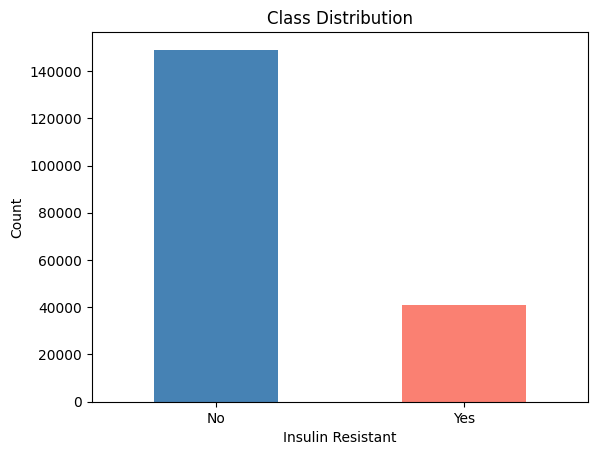

In [5]:
# Target distribution
df['Insulin_Resistant'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Insulin Resistant')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

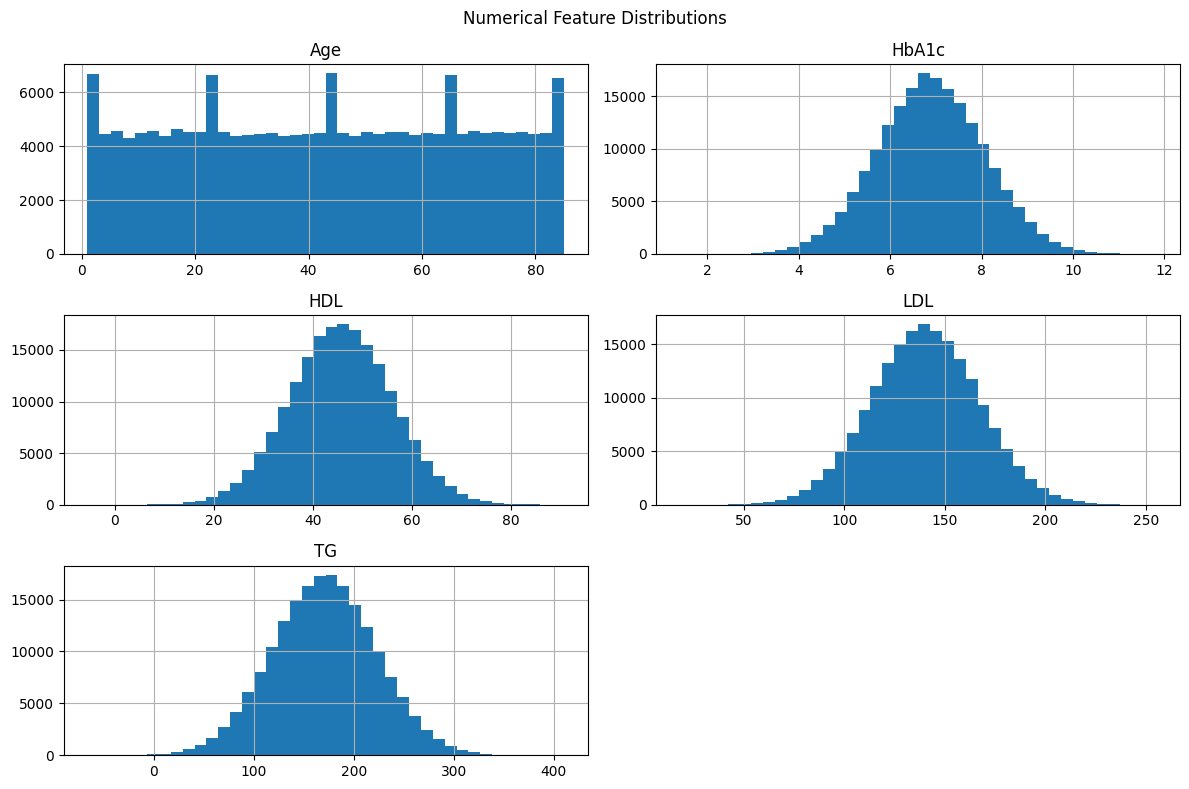

In [6]:
# Numerical feature distributions
num_cols = ['Age', 'HbA1c', 'HDL', 'LDL', 'TG']
df[num_cols].hist(figsize=(12, 8), bins=40)
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

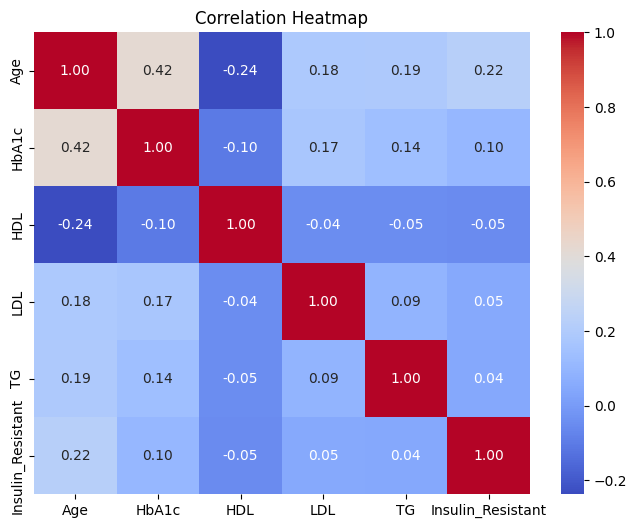

In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['Insulin_Resistant']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocessing

**Note on leaky features:** HOMA_IR, Fasting_Insulin, TG_HDL_Ratio, and Diabetic are removed because they either directly encode the target label or are near-perfect proxies for it, causing all models to score AUC = 1.0.

In [8]:
from sklearn.preprocessing import LabelEncoder

ENCODE_COLS = ['Country', 'Gender', 'Age_Group', 'Heart_Risk']
df_enc = df.copy()
label_encoders = {}

for col in ENCODE_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le

# Save all encoders in one file
with open('encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print('Label encoding done')

Label encoding done


In [9]:
LEAKY_FEATURES = ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'Diabetic']
X = df_enc.drop(columns=['ID', 'Insulin_Resistant'] + LEAKY_FEATURES)
y = df_enc['Insulin_Resistant']

print('Features:', X.columns.tolist())
print('Shape:', X.shape)

Features: ['Country', 'Year', 'Age', 'Gender', 'Age_Group', 'HbA1c', 'HDL', 'LDL', 'TG', 'Heart_Risk']
Shape: (190000, 10)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')

Train: 152000  Test: 38000


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## 4. SMOTE — Handle Class Imbalance

Applied only on training data. Test set is never touched.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

Before SMOTE: {0: np.int64(119219), 1: np.int64(32781)}
After  SMOTE: {0: np.int64(119219), 1: np.int64(119219)}


## 5. Model Training

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score

models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
}

In [14]:
# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"Model":<22} {"Accuracy":>10} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 52)

for name, model in models.items():
    cv = cross_validate(model, X_train_sm, y_train_sm, cv=skf,
                        scoring=['accuracy', 'f1', 'roc_auc'])
    print(f'{name:<22} {cv["test_accuracy"].mean():>10.4f} {cv["test_f1"].mean():>8.4f} {cv["test_roc_auc"].mean():>10.4f}')

Model                    Accuracy       F1    ROC-AUC
----------------------------------------------------
XGBoost                    0.8072   0.7701     0.8693


## 6. Grid Search — XGBoost Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':     [300, 600, 900, 1200],
    'max_depth':        [7, 9, 12],
    'learning_rate':    [0.05, 0.1, 0.2],
    'gamma':            [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0,
)

gs = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=2,
)

gs.fit(X_train_sm, y_train_sm)

print('\nGrid search complete.')
print(f'Total combinations tried: {len(gs.cv_results_["params"])}')


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=300; total time=   4.3s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=300; total time=   4.6s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=300; total time=   4.6s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=600; total time=   8.9s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=600; total time=   9.1s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=600; total time=   9.2s
[CV] END gamma=0, learning_rate=0.05, max_depth=9, n_estimators=300; total time=   6.4s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=900; total time=  13.2s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=900; total time=  13.3s
[CV] END gamma=0, learning_rate=0.05, max_depth=7, n_estimators=900; total time=  13.2s
[CV] END gamma=0, learning_rate=0.05, max_depth=9, n_esti

In [ ]:
# ── Best parameters found by Grid Search ─────────────────────────────────────
print('=' * 55)
print('        BEST HYPERPARAMETERS (Grid Search — XGBoost)')
print('=' * 55)
for param, value in gs.best_params_.items():
    print(f'  {param:<22} : {value}')
print('-' * 55)
print(f'  Best CV ROC-AUC        : {gs.best_score_:.4f}')
print('=' * 55)


## 7. Retrain Best XGBoost & Full Evaluation

In [ ]:
from sklearn.metrics import precision_score, recall_score

# ── Fresh train/test split using best params ──────────────────────────────────
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler2 = StandardScaler()
X_train2_sc = scaler2.fit_transform(X_train2)
X_test2_sc  = scaler2.transform(X_test2)

# Apply SMOTE only on training data
X_train2_sm, y_train2_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train2_sc, y_train2)

print(f'Train : {X_train2_sm.shape[0]}  Test : {X_test2.shape[0]}')

# ── Rebuild model with best params and fit fresh ──────────────────────────────
tuned_xgb = XGBClassifier(
    **gs.best_params_,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0,
)
tuned_xgb.fit(X_train2_sm, y_train2_sm)
print('Tuned XGBoost retrained on fresh split.')


In [ ]:
# ── Model Evaluation ─────────────────────────────────────────────────────────
y_pred_t = tuned_xgb.predict(X_test2_sc)

acc  = accuracy_score(y_test2, y_pred_t)
prec = precision_score(y_test2, y_pred_t)
rec  = recall_score(y_test2, y_pred_t)
f1   = f1_score(y_test2, y_pred_t)

print('=' * 45)
print('  Tuned XGBoost — Evaluation on Test Set')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 45)
print()
print(classification_report(y_test2, y_pred_t, target_names=['No IR', 'IR']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test2, y_pred_t)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No IR', 'IR'], yticklabels=['No IR', 'IR'])
plt.title('Confusion Matrix — Tuned XGBoost (Retrained)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Per-cell breakdown ────────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN) : {tn}')
print(f'False Positives (FP) : {fp}')
print(f'False Negatives (FN) : {fn}')
print(f'True Positives  (TP) : {tp}')


In [ ]:
# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(tuned_xgb, f)

print('Model saved to model.pkl')